## Lab 4: Tensor Products and Quantum Entanglement

__Objective:__ In this lab we calculate the entanglement entropy between the two subsystems of spin systems. We try to understand the concepts of tensor product, density matrix, reduced density matrix, and entanglement entropy. Catch: We calculate, mostly, bipartite entanglement, i.e., quantum entanglement between two subsystems, which can be either a single spin or a set of spins. Measures of multipartite entanglement are, however, not so well studied. 

__What will be covered?__
- Tensor product
- Expectation values
- Partial trace and quantum entanglement
- The CHSH game

### 1. Tensor Products

In [37]:
import numpy as np
from qutip import Qobj, basis, sigmax, sigmay, sigmaz, identity, tensor, expect
import matplotlib.pyplot as plt

%matplotlib inline

We can use qutip.tensor to compute the Kronecker tensor product of matrices $A$ and $B$. If $A$ is an $m$-by-$n$ matrix and $B$ is a $p$-by-$q$ matrix, then kron($A$,$B$) is an $mp$-by-$nq$ matrix formed by taking all possible products between the elements of $A$ and the matrix $B$:

$$ A \otimes B = \left ( 
    \begin{array}{cccc}
    a_{11} B & a_{12} B & \cdots & a_{1n} B \\
    a_{21} B & a_{22} B & \cdots & a_{2n} B \\
    \vdots & \vdots & \ddots & \vdots \\
    a_{n1} B & a_{n2} B & \cdots & a_{nn} B
    \end{array}
    \right ). $$ 


The state $\vert 00 \rangle \equiv \vert 0 \rangle \otimes \vert 0 \rangle$ that describes two qubits both in $\vert 0 \rangle$ can be created as follows.  

In [38]:
s = tensor(basis(2, 0), basis(2, 0))
print(s)

Quantum object: dims = [[2, 2], [1, 1]], shape = (4, 1), type = ket
Qobj data =
[[1.]
 [0.]
 [0.]
 [0.]]


An operator like $\hat O_1 \hat O_2$, such as $\sigma_1^x \sigma_2^x$, should then be represented in the same tensored space, where $\hat O_1 \equiv \hat O_1 \otimes I_2$ and $\hat O_2 \equiv I_1 \otimes \hat O_2$, such that 

$$
\hat O_1 \hat O_2 \equiv (\hat O_1 \otimes I_2) (I_1 \otimes \hat O_2).
$$

#### 1.1 An Example of Two Qubits

Consider two qubits in the dipolar coupling limit with an Hamiltonian (a Hermitian operator that we will explain in Lecture 5) can be written as 

$$ H \equiv H_0 + H_1 = - \left ( \frac{\Delta_1}{2} \sigma_1^z + \frac{\Delta_2}{2} \sigma_2^z \right ) + J \sigma_1^x \sigma_2^x, $$

where $\Delta_{1,2} = \Delta(1 \pm \delta/2)$ are the qubits' gaps.

In [39]:
Delta = 1.0
delta = 0.1
Delta1 = Delta * (1. + delta/2)
Delta2 = Delta * (1. - delta/2)
H0 = -0.5*(Delta1*tensor(sigmaz(),identity(2)) + Delta2*tensor(identity(2),sigmaz()))

J = 0.1
H1 = J * tensor(sigmax(), sigmax())

H = H0 + H1

print('H0 =', H0)
print('H1 =', H1)
print('H =', H)

H0 = Quantum object: dims = [[2, 2], [2, 2]], shape = (4, 4), type = oper, isherm = True
Qobj data =
[[-1.    0.    0.    0.  ]
 [ 0.   -0.05  0.    0.  ]
 [ 0.    0.    0.05  0.  ]
 [ 0.    0.    0.    1.  ]]
H1 = Quantum object: dims = [[2, 2], [2, 2]], shape = (4, 4), type = oper, isherm = True
Qobj data =
[[0.  0.  0.  0.1]
 [0.  0.  0.1 0. ]
 [0.  0.1 0.  0. ]
 [0.1 0.  0.  0. ]]
H = Quantum object: dims = [[2, 2], [2, 2]], shape = (4, 4), type = oper, isherm = True
Qobj data =
[[-1.    0.    0.    0.1 ]
 [ 0.   -0.05  0.1   0.  ]
 [ 0.    0.1   0.05  0.  ]
 [ 0.1   0.    0.    1.  ]]


In [40]:
w0,v0 = H0.eigenstates()
print('E_0 =', w0)
print(v0, '\n')


E_0 = [-1.   -0.05  0.05  1.  ]
[Quantum object: dims = [[2, 2], [1, 1]], shape = (4, 1), type = ket
 Qobj data =
 [[1.]
  [0.]
  [0.]
  [0.]]
 Quantum object: dims = [[2, 2], [1, 1]], shape = (4, 1), type = ket
 Qobj data =
 [[0.]
  [1.]
  [0.]
  [0.]]
 Quantum object: dims = [[2, 2], [1, 1]], shape = (4, 1), type = ket
 Qobj data =
 [[0.]
  [0.]
  [1.]
  [0.]]
 Quantum object: dims = [[2, 2], [1, 1]], shape = (4, 1), type = ket
 Qobj data =
 [[0.]
  [0.]
  [0.]
  [1.]]                                                             ] 



In the next lecture, we will understand that the effect of $H_1$ on two of the eigenstates $\vert 00 \rangle$ and $\vert 11 \rangle$ can be neglected, with corrections $O[J^2/(2\Delta)] \sim 0.5\%$. 

In [41]:
w,v = H.eigenstates()
print('E =', w)
print(v, '\n')

print('(Delta E) / E_0 =', (w - w0)/w0)

E = [-1.00498756 -0.1118034   0.1118034   1.00498756]
[Quantum object: dims = [[2, 2], [1, 1]], shape = (4, 1), type = ket
 Qobj data =
 [[ 0.99875853]
  [ 0.        ]
  [ 0.        ]
  [-0.0498137 ]]
 Quantum object: dims = [[2, 2], [1, 1]], shape = (4, 1), type = ket
 Qobj data =
 [[ 0.        ]
  [ 0.85065081]
  [-0.52573111]
  [ 0.        ]]
 Quantum object: dims = [[2, 2], [1, 1]], shape = (4, 1), type = ket
 Qobj data =
 [[0.        ]
  [0.52573111]
  [0.85065081]
  [0.        ]]
 Quantum object: dims = [[2, 2], [1, 1]], shape = (4, 1), type = ket
 Qobj data =
 [[0.0498137 ]
  [0.        ]
  [0.        ]
  [0.99875853]]                                                     ] 

(Delta E) / E_0 = [0.00498756 1.23606798 1.23606798 0.00498756]


#### 1.2 Generalization to Multiple Qubits

In the following, we define single-spin operators in the multispin Hilbert space with qutip.tensor. 

In [42]:
def spin_operators(nspin, sigmas=None):
    ''' Define the list of spin operators in the multi-spin basis. 
        For higher spins, one can define 
          sigmas = [qt.jmat(j, 'x'), qt.jmat(j, 'y'), qt.jmat(j, 'z')]
    '''
    sx_list = []
    sy_list = []
    sz_list = []
    if not sigmas: # default: Pauli matrices
        sigmas = [sigmax(), sigmay(), sigmaz()]
    d = sigmas[0].shape[0]

    for ispin in range(nspin):
        if ispin == 0:
            sx = sigmas[0]
            sy = sigmas[1]
            sz = sigmas[2]
        else:
            sx = identity(d)
            sy = identity(d)
            sz = identity(d)

        for jspin in range(1, nspin):
            if jspin == ispin:
                sx = tensor(sx,sigmas[0])
                sy = tensor(sy,sigmas[1])
                sz = tensor(sz,sigmas[2])
            else:
                sx = tensor(sx,identity(d))
                sy = tensor(sy,identity(d))
                sz = tensor(sz,identity(d))

        sx_list.append(sx)
        sy_list.append(sy)
        sz_list.append(sz)

    return sx_list,sy_list,sz_list

In [43]:
N = 2
d = 2
sx_list,sy_list,sz_list = spin_operators(N)
for i, sx, sy, sz in zip(np.arange(len(sx_list)), sx_list, sy_list, sz_list):
    print('--- Spin', i + 1, '---\n\n', sx, '\n\n', sy, '\n\n', sz, '\n')

--- Spin 1 ---

 Quantum object: dims = [[2, 2], [2, 2]], shape = (4, 4), type = oper, isherm = True
Qobj data =
[[0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]] 

 Quantum object: dims = [[2, 2], [2, 2]], shape = (4, 4), type = oper, isherm = True
Qobj data =
[[0.+0.j 0.+0.j 0.-1.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.-1.j]
 [0.+1.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+1.j 0.+0.j 0.+0.j]] 

 Quantum object: dims = [[2, 2], [2, 2]], shape = (4, 4), type = oper, isherm = True
Qobj data =
[[ 1.  0.  0.  0.]
 [ 0.  1.  0.  0.]
 [ 0.  0. -1.  0.]
 [ 0.  0.  0. -1.]] 

--- Spin 2 ---

 Quantum object: dims = [[2, 2], [2, 2]], shape = (4, 4), type = oper, isherm = True
Qobj data =
[[0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]] 

 Quantum object: dims = [[2, 2], [2, 2]], shape = (4, 4), type = oper, isherm = True
Qobj data =
[[0.+0.j 0.-1.j 0.+0.j 0.+0.j]
 [0.+1.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.-1.j]
 [0.+0.j 0.+0.j 0.+1.j 0.+0.j]] 

 Quantum object: dims = 

The following routine defines the nearest-neighbor antiferromagnetic interaction (such that the spins tend to align antiparallel with its neighbors) of a ring of spins (qubits)

$$ \vec \sigma_1 \cdot \vec \sigma_2 + \vec \sigma_2 \cdot \vec \sigma_3 + \cdots + \vec \sigma_{N - 1} \cdot \vec \sigma_N + \vec \sigma_N \cdot \vec \sigma_1. $$

In [44]:
def hamiltonian(sx_list,sy_list,sz_list):
    ''' The interaction operator (Hamiltonian) for the nearest-neighbor interaction only. '''
    nspin = len(sx_list)
    ham = Qobj(dims=sx_list[0].dims)

    for i in range(nspin):
        j = np.mod(i+1, nspin) # periodic boundary conditions
        ham = ham + sz_list[i] * sz_list[j]
        ham = ham + sx_list[i] * sx_list[j]
        ham = ham + sy_list[i] * sy_list[j]

    return ham

In [45]:
h = hamiltonian(sx_list,sy_list,sz_list)
e, v = h.eigenstates()
print (e)
print (v)

[-6.  2.  2.  2.]
[Quantum object: dims = [[2, 2], [1, 1]], shape = (4, 1), type = ket
 Qobj data =
 [[ 0.        ]
  [ 0.70710678]
  [-0.70710678]
  [ 0.        ]]
 Quantum object: dims = [[2, 2], [1, 1]], shape = (4, 1), type = ket
 Qobj data =
 [[0.        ]
  [0.70710678]
  [0.70710678]
  [0.        ]]
 Quantum object: dims = [[2, 2], [1, 1]], shape = (4, 1), type = ket
 Qobj data =
 [[1.]
  [0.]
  [0.]
  [0.]]
 Quantum object: dims = [[2, 2], [1, 1]], shape = (4, 1), type = ket
 Qobj data =
 [[0.]
  [0.]
  [0.]
  [1.]]                                                             ]


### 2. Expectation Values

#### 2.1 Single qubit

Suppose a qubit is in the state of $(\vert 0 \rangle + \vert 1 \rangle)/\sqrt{2}$. 

In [46]:
psi = (basis(2, 0) + basis(2, 1)).unit()

If we measure the spin along $z$ axis, i.e. $\sigma_z$ is the operator associated with the measurement, the expectation value or the average value of the measurement is

In [47]:
expect(sigmaz(), psi)

0.0

The expectation value vanishes simply because we have an equal superposition of spin up and spin down. Alternatively, we can say we have no information on the spin direction along $z$ axis. Now if we measure the spin along $x$ axis, we find

In [48]:
expect(sigmax(), psi)

0.9999999999999998

The spin is pointing along the +$x$ direction; we know for certain. We see that the expectation value reveals the information of a quantum state. 

#### 2.2 Two qubits

Let us start with the eigenstate with the lowest eigenerergy of the interaction operator of two antiferromagnetically coupled spins. We call this state the ground state. The state, up to a global phase, is one of the Bell states

$$ \vert \psi_{gs} \rangle = \frac{1}{\sqrt{2}} \left ( \vert 10 \rangle - \vert 01 \rangle \right ). $$

In [49]:
N = 2
s = tensor(N*[basis(d, 0)]) # We keep N for easy generalization to N > 2. 
psi_gs = v[0]
print(psi_gs)

Quantum object: dims = [[2, 2], [1, 1]], shape = (4, 1), type = ket
Qobj data =
[[ 0.        ]
 [ 0.70710678]
 [-0.70710678]
 [ 0.        ]]


Now pick a random direction $\hat n$ and measure the first spin along the direction. 

In [ ]:
elist = []
for _ in range(100):
    cos_theta = 2. * np.random.rand() - 1.
    sin_theta = np.sqrt(1. - cos_theta**2)
    phi = 2 * np.pi * np.random.rand()
    sigma_n = sigmax()*sin_theta*np.cos(phi) + sigmay()*sin_theta*np.sin(phi) + sigmaz()*cos_theta
    elist.append(expect(tensor(sigma_n, identity(2)), psi_gs))

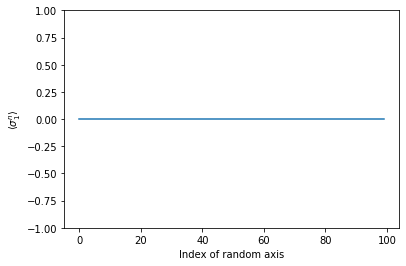

In [51]:
plt.plot(elist, label=r'$\langle \sigma_{1}^n \rangle$')
plt.xlabel('Index of random axis')
plt.ylabel(r'$\langle \sigma_{1}^n \rangle$')
plt.ylim((-1,1))
plt.show()

The expectation value always vanishes, implying that we can predict nothing about the outcome of individual measurements. 

### 3. Partial Trace and Quantum Entanglement

The partial trace is an operation that reduces the dimension of a Hilbert space by eliminating some degrees of freedom by averaging (tracing). In this sense it is therefore the converse of the tensor product. It is useful when one is interested in only a part of a coupled quantum system. 

In [52]:
rhoA = psi_gs.ptrace(0)
print(rhoA)

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[0.5 0. ]
 [0.  0.5]]


In [53]:
help(Qobj.ptrace)

Help on function ptrace in module qutip.qobj:

ptrace(self, sel, sparse=None)
    Partial trace of the quantum object.
    
    Parameters
    ----------
    sel : int/list
        An ``int`` or ``list`` of components to keep after partial trace.
        The order is unimportant; no transposition will be done and the
        spaces will remain in the same order in the output.
    
    Returns
    -------
    oper : :class:`qutip.Qobj`
        Quantum object representing partial trace with selected components
        remaining.
    
    Notes
    -----
    This function is identical to the :func:`qutip.qobj.ptrace` function
    that has been deprecated.



In QuTiP the class method qutip.Qobj.ptrace is used to take partial traces. It takes one argument (0 in this case), which specifies a list of integers that mark the component systems that should be kept. All other components are traced out. Note that the partial trace always results in a density matrix (mixed state).

The von Neumann (Shannon) entropy of the eigenenergies of the reduced density matrix measures the amount of entanglement between the two subsystems.

In [54]:
lambdas = rhoA.eigenenergies()
entanglement_entropy = np.sum(-np.log2(lambdas)*lambdas)
print(entanglement_entropy)

0.9999999999999999


In this case, the two spins are coupled with the maximum amount of entanglement between them. 

### 4. The CHSH Game

In the CHSH game, two players Alice and Bob communicate only with a referee, 
who randomly select a single-bit question for each player. 
The players receive the question ($r$, $s$) and are required to answer with a single bit.  
The referee then checks the answers ($a$, $b$) of Alice and Bob and determine whether 
the players win or lose. 

<center>
<img src="Lab04_chsh_game.png" width="400">
</center>

The winning conditions are $a \oplus b = r \wedge s$, i.e., $a \oplus b = 0,0,0,1$, respectively, 
for questions $rs = 00,01,10,11$.

Can Alice and Bob win every time?
  - Let us write $a_r$ as the answer of Alice for question $r$ and, similarly, 
  $b_s$ as the answer of Bob for question $s$.
  - The winning conditions can be expressed as 
  $$
  a_0 \oplus b_0 = 0, \quad a_0 \oplus b_1 = 0, \quad
  a_1 \oplus b_0 = 0, \quad a_1 \oplus b_1 = 1.
  $$
  - It is not possible to win every time as adding the four equations modulo 2 gives $0 = 1$. 


---

## Lab 4 Exercises

Student Name: 任子桐，司浩言，余承恩

Student ID: 3240104990，3230105125，3240100479

Date: 2026/3/23

### E1. The CHSH Game with Classical Strategies

Simulate the CHSH game with classical stategies. 
What is the maximum probability of winning the game using a classical strategy? 
What if Alice and Bob use a probabilistic, instead of deterministic, strategy?


The result is given by the following python code: if Alice and Bob use a classical deterministic strategy, then the maximum probability of winning the game is 75%.

In [ ]:
# 定义裁判可能给出的问题组合(r, s)，共四种
questions = [(0, 0), (0, 1), (1, 0), (1, 1)]

# 使用字典定义玩家的经典“确定性策略”空间，根据收到问题给出对应答案
strategies = [
    {0: 0, 1: 0},
    {0: 0, 1: 1},
    {0: 1, 1: 0},
    {0: 1, 1: 1}
]

max_win_rate = 0.0

# 模拟所有可能的策略组合，两人分别有四种策略，共 16 种
for alice_strategy in strategies:
    for bob_strategy in strategies:
        wins = 0
        
        for r, s in questions:
            a = alice_strategy[r]
            b = bob_strategy[s]
            
            if (a ^ b) == (r & s):
                wins += 1
                
        win_rate = wins / len(questions)
        
        if win_rate > max_win_rate:
            max_win_rate = win_rate

print(f"模拟 16 种经典策略组合")
print(f"最高胜率: {max_win_rate * 100}%")

Actually, if Alice and Bob use classical probabilistic strategy, then the maximum probability of winning this game will still be no more than 75%. If Alice and Bob have the possibility to use different strategies, then the final winning probability can be considered as a weighted average of multiple probabilities of multiple deterministic strategy (where the weights is determined by the possibility of using different deterministic startegies). We already know that the maximum winning probability of a single deterministic strategy is 75%, so no matter what kind of probabilistic strategy that Alice and Bob use, the final winning probability will not be more than 75%.

### E2. The CHSH Game with a Quantum Strategy

Suppose Alice and Bob are allowed to share an entangled state 
$$ 
\vert \psi \rangle = \frac1{\sqrt2} (\vert 00 \rangle + \vert 11 \rangle),
$$
and they can perform quantum measurements to observables 
$$ A_0 = \sigma_z \equiv
\begin{pmatrix}
1 & 0 \\ 0 & -1
\end{pmatrix},
\quad 
A_1 = \sigma_x \equiv
\begin{pmatrix}
0 & 1 \\ 1 & 0
\end{pmatrix}
$$
for Alice and
$$ B_0 = \frac1{\sqrt2} (\sigma_z + \sigma_x) =
\frac1{\sqrt2}
\begin{pmatrix}
1 & 1 \\ 1 & -1
\end{pmatrix},
\quad 
B_1 = \frac1{\sqrt2} (\sigma_z - \sigma_x) =
\frac1{\sqrt2}
\begin{pmatrix}
1 & -1 \\ -1 & -1
\end{pmatrix}
$$
for Bob. 
Now, for question $r$, Alice measures $A_r$ and answers $a$ with measurement outcomes $(-1)^a$. And similarly for Bob. 
Simulate the quantum strategy and calculate the probability of winning the game. 

In fact, the probability that Alice and Bob win minus the probability they lose is 
$$
\frac{1}{4} \langle \psi \vert A_0 \otimes B_0 + A_0 \otimes B_1 + A_1 \otimes B_0 - A_1 \otimes B_1 \vert \psi \rangle.
$$
Verify this result by your simulation. 